# TMDB Movie Data Analysis using Pandas and APIs

## Project Overview

This project challenges you to build a movie data analysis pipeline using Python and Pandas.

You will fetch movie-related data from an API, clean and transform the dataset, and implement key performance indicators (KPIs).

This is not a group project, meaning you will design the workflow, structure the analysis, and implement the required calculations independently.

## Project Objectives

   - API Data Extraction: Fetch movie data from a movie database API.

   - Data Cleaning & Transformation: Process and structure the data for analysis.

   - Exploratory Data Analysis (EDA): Perform an initial exploration to understand trends.

   - Advanced Filtering & Ranking: Identify the best and worst movies based on financial and popularity metrics.

   - Franchise & Director Analysis: Assess how franchises and directors perform over time.

   - Visualization & Insights: Present key findings using visualizations.


In [46]:
from __future__ import annotations

from pathlib import Path
import sys

project_root = Path.cwd().resolve().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

from config import get_settings
from tmdb_movie.utils.api import get_movies_dataframe_from_ids

### Step 1: Fetch Movie Data from API

   - Choose a movie database API (e.g., TMDb).

   - Fetch movies with ID:

   - movie_id = [0, 299534, 19995, 140607, 299536, 597, 135397, 420818, 24428, 168259, 99861, 284054, 12445, 181808, 330457, 351286, 109445, 321612, 260513]

   - Store the data as a Pandas DataFrame.

   - NB: Read the API documentation to understand the nature of the data and how it's organized.


In [2]:
# Download movies
MOVIE_IDS = [
    0,
    299534,
    19995,
    140607,
    299536,
    597,
    135397,
    420818,
    24428,
    168259,
    99861,
    284054,
    12445,
    181808,
    330457,
    351286,
    109445,
    321612,
    260513,
]

df = get_movies_dataframe_from_ids(settings=get_settings(), movie_ids=MOVIE_IDS)

In [3]:
df.head()

,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,...,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,cast,crew
0,NaN,NaN,NaN,NaN,[],NaN,0,NaN,NaN,NaN,...,NaN,[],NaN,NaN,NaN,NaN,NaN,NaN,[],[]
1,False,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,"{'id': 86311, 'name': 'The Avengers Collection...",356000000.0,"[{'id': 12, 'name': 'Adventure'}, {'id': 878, ...",https://www.marvel.com/movies/avengers-endgame,299534,tt4154796,en,Avengers: Endgame,...,181.0,"[{'iso_639_1': 'en', 'name': 'English', 'engli...",Released,Avenge the fallen.,Avengers: Endgame,False,8.200,27363.0,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ..."
2,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,"{'id': 87096, 'name': 'Avatar Collection', 'po...",237000000.0,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",https://www.avatar.com/movies/avatar,19995,tt0499549,en,Avatar,...,162.0,"[{'iso_639_1': 'en', 'name': 'English', 'engli...",Released,Enter the world of Pandora.,Avatar,False,7.600,33599.0,"[{'adult': False, 'gender': 2, 'id': 65731, 'k...","[{'adult': False, 'gender': 2, 'id': 58871, 'k..."
3,False,/8BTsTfln4jlQrLXUBquXJ0ASQy9.jpg,"{'id': 10, 'name': 'Star Wars Collection', 'po...",245000000.0,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",http://www.starwars.com/films/star-wars-episod...,140607,tt2488496,en,Star Wars: The Force Awakens,...,136.0,"[{'iso_639_1': 'en', 'name': 'English', 'engli...",Released,Every generation has a story.,Star Wars: The Force Awakens,False,7.250,20342.0,"[{'adult': False, 'gender': 1, 'id': 1315036, ...","[{'adult': False, 'gender': 2, 'id': 15344, 'k..."
4,False,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,"{'id': 86311, 'name': 'The Avengers Collection...",300000000.0,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",https://www.marvel.com/movies/avengers-infinit...,299536,tt4154756,en,Avengers: Infinity War,...,149.0,"[{'iso_639_1': 'en', 'name': 'English', 'engli...",Released,Destiny arrives all the same.,Avengers: Infinity War,False,8.234,31597.0,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ..."


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  18 non-null     object 
 1   backdrop_path          18 non-null     str    
 2   belongs_to_collection  16 non-null     str    
 3   budget                 18 non-null     float64
 4   genres                 19 non-null     str    
 5   homepage               18 non-null     str    
 6   id                     19 non-null     int64  
 7   imdb_id                18 non-null     str    
 8   original_language      18 non-null     str    
 9   original_title         18 non-null     str    
 10  overview               18 non-null     str    
 11  popularity             18 non-null     float64
 12  poster_path            18 non-null     str    
 13  production_companies   19 non-null     str    
 14  production_countries   19 non-null     str    
 15  release_date       

In [7]:
df.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,1.800000e+01,19.000000,18.000000,1.800000e+01,18.000000,18.000000,18.00000
mean,2.137778e+08,182139.578947,16.916744,1.691832e+09,138.055556,7.393000,20805.50000
std,6.195972e+07,136090.306553,10.203019,5.210623e+08,23.848720,0.512955,8075.39537
min,1.250000e+08,0.000000,8.661500,1.243226e+09,102.000000,6.532000,10185.00000
25%,1.625000e+08,62144.500000,10.686950,1.334902e+09,125.250000,7.129500,14148.00000
50%,2.000000e+08,168259.000000,12.501100,1.484542e+09,135.500000,7.260000,20863.00000
75%,2.430000e+08,299535.000000,18.150350,1.957196e+09,147.500000,7.826500,26206.00000
max,3.560000e+08,420818.000000,47.958800,2.923706e+09,194.000000,8.234000,36446.00000


In [8]:
# Missing %
(
    df
    .isna()
    .mean()
    .mul(100)
    .to_frame(name='missing_pct')
    .sort_values('missing_pct', ascending=False)
)

,missing_pct
belongs_to_collection,15.789474
adult,5.263158
backdrop_path,5.263158
budget,5.263158
homepage,5.263158
original_language,5.263158
imdb_id,5.263158
original_title,5.263158
overview,5.263158
poster_path,5.263158


In [9]:
# Columns with objects or lists
json_cols = ['belongs_to_collection', 'genres', 'production_countries',
             'production_companies', 'spoken_languages'] #ignoring "crew", "cast" too huge

for col in json_cols:
    if col in df.columns:
        sample_val = df[col].iloc[2]
        print(f"Column: {col} | Type: {type(sample_val)}")
        print(f"Sample Content: {sample_val}\n")


Column: belongs_to_collection | Type: <class 'str'>
Sample Content: {'id': 87096, 'name': 'Avatar Collection', 'poster_path': '/3C5brXxnBxfkeKWwA1Fh4xvy4wr.jpg', 'backdrop_path': '/6qkJLRCZp9Y3ovXti5tSuhH0DpO.jpg'}

Column: genres | Type: <class 'str'>
Sample Content: [{'id': 28, 'name': 'Action'}, {'id': 12, 'name': 'Adventure'}, {'id': 878, 'name': 'Science Fiction'}]

Column: production_countries | Type: <class 'str'>
Sample Content: [{'iso_3166_1': 'US', 'name': 'United States of America'}, {'iso_3166_1': 'GB', 'name': 'United Kingdom'}]

Column: production_companies | Type: <class 'str'>
Sample Content: [{'id': 444, 'name': 'Dune Entertainment', 'logo_path': None, 'origin_country': 'US'}, {'id': 574, 'name': 'Lightstorm Entertainment', 'logo_path': '/8wdmrfGcDx3TJxYiiDksLzAW4pB.png', 'origin_country': 'US'}, {'id': 25, 'name': '20th Century Fox', 'logo_path': '/qZCc1lty5FzX30aOCVRBLzaVmcp.png', 'origin_country': 'US'}, {'id': 133789, 'name': 'Ingenious Film Partners', 'logo_path':

In [10]:
#  Categorical Distribution
(
    df[['status', 'original_language']]
    .melt(var_name='column', value_name='value')
    .value_counts()
    .to_frame(name='count')
)

,,count
column,value,
status,Released,18
original_language,en,18


In [11]:
# checking zeros financial columns
(
    (df[['budget', 'revenue', 'runtime']] == 0)
    .sum()
    .to_frame(name='count_of_zeros')
)

,count_of_zeros
budget,0
revenue,0
runtime,0


## Step 2: Data Cleaning and Preprocessing

### Data Preparation & Cleaning

   1. Drop irrelevant columns: ['adult', 'imdb_id', 'original_title', 'video', 'homepage'].

   2. Evaluate JSON-like columns (['belongs_to_collection', 'genres', 'production_countries', 'production_companies', 'spoken_languages']).

   3. Extract and clean key data points:

        - Collection name (belongs_to_collection)

        - Genre names (genres → separate multiple genres with "|").

        - Spoken languages (spoken_languages → separate with "|").

        - Production countries (production_countries → separate with "|").

        - Production companies (production_companies → separate with "|").

   4. Inspect extracted columns using value_counts() to identify anomalies.

Handling Missing & Incorrect Data


   5. Convert column datatypes:

        'budget', 'id', 'popularity' → Numeric (set invalid values to NaN).
        'release_date' → Convert to datetime.
        etc

   6. Replace unrealistic values:

        Budget/Revenue/Runtime $= 0$ → Replace with NaN or infer from similar movies.
        Convert 'budget' and 'revenue' to million USD.
        Movies with vote_count = 0 → Analyze their vote_average and adjust accordingly.
        'overview' and 'tagline' → Replace known placeholders (e.g., 'No Data') with NaN.

   7. Remove duplicates and drop rows with unknown 'id' or 'title'.

   8. Keep only rows where at least 10 columns have non-NaN values.

   9. Filter to include only 'Released' movies, then drop 'status'.

**Reorder & Finalize DataFrame**

   10. Reorder columns:

   ```
    ['id', 'title', 'tagline', 'release_date', 'genres', 'belongs_to_collection', 'original_language',
        'budget_musd', 'revenue_musd', 'production_companies', 'production_countries', 'vote_count', 'vote_average',
        'popularity', 'runtime', 'overview', 'spoken_languages', 'poster_path', 'cast', 'cast_size', 'director', 'crew_size']
   ```
   11. Reset index.


In [68]:
def safe_parse(val, key='name'):
    """Parses JSON-like strings and extracts a specific key, joined by '|'."""
    if isinstance(val, list):
        return "|".join([i[key] for i in val if key in i])

    if isinstance(val, dict):
        return val.get(key, np.nan)

    if isinstance(val, str):
        if val == "[]" or val == "{}":
            return np.nan
        try:
            # Convert string representation of list/dict to a python object
            data = ast.literal_eval(val)
            if isinstance(data, list):
                return "|".join([i[key] for i in data if key in i])
            if isinstance(data, dict):
                return data.get(key, np.nan)
        except (ValueError, SyntaxError):
            return np.nan

    return np.nan

def extract_director(crew_list):
    if isinstance(crew_list, list):
        directors = [m['name'] for m in crew_list if m.get('job') == 'Director']
        return "|".join(directors) if directors else np.nan

    elif isinstance(crew_list, str):
        data = ast.literal_eval(crew_list)
        if isinstance(data, list):
            directors = [m['name'] for m in data if m.get('job') == 'Director']
            return "|".join(directors) if directors else np.nan

    return np.nan


def extract_cast(cast_list):
    if isinstance(cast_list, list):
        return "|".join([m['name'] for m in cast_list])

    elif isinstance(cast_list, str):
        data = ast.literal_eval(cast_list)
        if isinstance(data, list):
            return "|".join([m['name'] for m in data])

    return np.nan


def safe_len(value):
    if isinstance(value, (list, dict)):
        return len(value)

    if isinstance(value, str):
        data = ast.literal_eval(value)
        if isinstance(data, (list, dict)):
            return len(data)
        return len(value)

    if pd.isna(value):
        return np.nan
    return np.nan

In [69]:
# Define the columns to drop
cols_to_drop = ['adult', 'imdb_id', 'original_title', 'video', 'homepage']

# Define the final column order as per instructions
final_column_order = [
    'id', 'title', 'tagline', 'release_date', 'genres', 'belongs_to_collection',
    'original_language', 'budget_musd', 'revenue_musd', 'production_companies',
    'production_countries', 'vote_count', 'vote_average', 'popularity', 'runtime',
    'overview', 'spoken_languages', 'poster_path', 'cast', 'cast_size', 'director', 'crew_size'
]

# Cleaning pipeline using chaining
df_cleaned = (
    df
    # Drop irrelevant columns
    .drop(columns=[c for c in cols_to_drop if c in df.columns])

    # Extract data from JSON-like columns
    .assign(
        belongs_to_collection = df['belongs_to_collection'].apply(safe_parse),
        genres = df['genres'].apply(safe_parse),
        spoken_languages = df['spoken_languages'].apply(safe_parse, key="english_name"),
        production_countries = df['production_countries'].apply(safe_parse),
        production_companies = df['production_companies'].apply(safe_parse),
        director = df['crew'].apply(extract_director),
        cast_size = df['cast'].apply(safe_len),
        crew_size = df['crew'].apply(safe_len),
        cast = df['cast'].apply(extract_cast),
    )

    # Convert types & Handle Zeros
    .assign(
        id = pd.to_numeric(df['id'], errors='coerce'),
        budget = pd.to_numeric(df['budget'], errors='coerce').replace(0, np.nan),
        revenue = pd.to_numeric(df['revenue'], errors='coerce').replace(0, np.nan),
        runtime = pd.to_numeric(df['runtime'], errors='coerce').replace(0, np.nan),
        popularity = pd.to_numeric(df['popularity'], errors='coerce'),
        release_date = pd.to_datetime(df['release_date'], errors='coerce'),
        vote_count = pd.to_numeric(df['vote_count'], errors='coerce').fillna(0),
    )


    # Impute values: Runtime with median, Vote Average with NaN if no votes
    .assign(
        runtime = df['runtime'].fillna(df['runtime'].median()),
        vote_average = pd.to_numeric(df['vote_average'], errors='coerce')
                            .mask(df['vote_count'] == 0, np.nan)
    )

    # Convert to Millions USD
    .assign(
        budget_musd = df['budget'] / 1_000_000,
        revenue_musd = df['revenue'] / 1_000_000
    )

    # Clean up strings & handle placeholders
    .assign(
        overview = df['overview'].replace(['No Data', ''], np.nan),
        tagline = df['tagline'].replace(['No Data', ''], np.nan)
    )

    # Filter: Only Released movies & Drop status
    .query("status == 'Released'")
    .drop(columns=['status', 'crew'], errors='ignore')

    # Drop duplicates and ensure columns aren't NaN
    .dropna(subset=['id', 'title'])
    .drop_duplicates(subset=['id'])

    # Keep only rows with at least 10 non-NaN values
    .dropna(thresh=10)

    # Reorder columns
    .reindex(columns=final_column_order)
    .reset_index(drop=True)
)

df_cleaned.head(30)

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,vote_average,popularity,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Adventure|Science Fiction|Action,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,8.200,18.7572,181.0,After the devastating events of Avengers: Infi...,English|Japanese|Xhosa,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,104,Anthony Russo|Joe Russo,610
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,Dune Entertainment|Lightstorm Entertainment|20...,...,7.600,28.3235,162.0,"In the 22nd century, a paraplegic Marine is di...",English|Spanish,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,67,James Cameron,996
2,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Adventure|Action|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Lucasfilm Ltd.|Bad Robot,...,7.250,10.8208,136.0,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,265
3,299536,Avengers: Infinity War,Destiny arrives all the same.,2018-04-25,Adventure|Action|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,8.234,29.2401,149.0,As the Avengers and their allies have continue...,English|Xhosa,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,69,Joe Russo|Anthony Russo,737
4,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama|Romance,NaN,en,200.0,2264.162353,Paramount Pictures|20th Century Fox|Lightstorm...,...,7.902,27.1197,194.0,101-year-old Rose DeWitt Bukater tells the sto...,English|French|German|Swedish|Italian|Russian,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,116,James Cameron,264
5,135397,Jurassic World,The park is open.,2015-06-06,Action|Adventure|Science Fiction|Thriller,Jurassic Park Collection,en,150.0,1671.537444,Amblin Entertainment|Universal Pictures|Legend...,...,6.699,11.5898,124.0,Twenty-two years after the events of Jurassic ...,English,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,53,Colin Trevorrow,428
6,420818,The Lion King,The king has returned.,2019-07-12,Adventure|Drama|Family|Animation,The Lion King (Reboot) Collection,en,260.0,1662.020819,Walt Disney Pictures|Fairview Entertainment,...,7.100,9.6750,118.0,"Simba idolizes his father, King Mufasa, and ta...",English,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,Chiwetel Ejiofor|John Oliver|Donald Glover|Jam...,20,Jon Favreau,52
7,24428,The Avengers,Some assembly required.,2012-04-25,Science Fiction|Action|Adventure,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,7.965,47.9588,143.0,When an unexpected enemy emerges and threatens...,English|Hindi|Russian,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,642
8,168259,Furious 7,Vengeance hits home.,2015-04-01,Action|Crime|Thriller,The Fast and the Furious Collection,en,190.0,1515.400000,Original Film|One Race|Universal Pictures,...,7.218,10.4080,139.0,Deckard Shaw seeks revenge against Dominic Tor...,Arabic|English|Spanish|Thai,/ktofZ9Htrjiy0P6LEowsDaxd3Ri.jpg,Vin Diesel|Paul Walker|Dwayne Johnson|Michelle...,49,James Wan,230
9,99861,Avengers: Age of Ultron,A new age has come.,2015-04-22,Action|Adventure|Science Fiction,The Avengers Collection,en,235.0,1405.403694,Marvel Studios,...,7.270,15.7612,141.0,When Tony Stark tries to jumpstart a dormant p...,English,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...,74,Joss Whedon,655


## Step 3: KPI Implementation & Analysis

### Identify the Best/Worst Performing Movies

   1. Filter and rank movies based on:

        - Highest Revenue

        - Highest Budget

        - Highest Profit (Revenue - Budget)

        - Lowest Profit (Revenue - Budget)

        - Highest ROI (Revenue / Budget) (only movies with Budget $\ge 10M$)

        - Lowest ROI (only movies with Budget $\ge 10M$)

        - Most Voted Movies

        - Highest Rated Movies (only movies with $\ge 10$ votes)

        - Lowest Rated Movies (only movies with $\ge 10$ votes)

        - Most Popular Movies

   - Define a User-Defined Function (UDF) to streamline ranking operations.

Advanced Movie Filtering & Search Queries

   3. Filter the dataset for specific queries:

        - Search 1: Find the best-rated Science Fiction Action movies starring Bruce Willis (sorted by Rating - highest to lowest).
        - Search 2: Find movies starring Uma Thurman, directed by Quentin Tarantino (sorted by runtime - shortest to longest).

#### Franchise vs. Standalone Movie Performance

   4. Compare movie franchises (belongs_to_collection) vs. standalone movies in terms of:

        - Mean Revenue
        - Median ROI
        - Mean Budget Raised
        - Mean Popularity
        - Mean Rating

#### Most Successful Franchises & Directors

   5. Find the Most Successful Movie Franchises based on:

        - Total number of movies in franchise
        - Total & Mean Budget
        - Total & Mean Revenue
        - Mean Rating

   6. Find the Most Successful Directors based on:

        - Total Number of Movies Directed
        - Total Revenue
        - Mean Rating


In [24]:
# Add Profit and ROI columns to our cleaned dataframe
df_final = df_cleaned.assign(
    profit_musd =  df_cleaned['revenue_musd'] - df_cleaned['budget_musd'],
    roi = df_cleaned['revenue_musd'] / df_cleaned['budget_musd']
)

df_final

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Adventure|Science Fiction|Action,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,181.0,After the devastating events of Avengers: Infi...,English|Japanese|Xhosa,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,32492,Anthony Russo|Joe Russo,176753,2443.439100,7.863593
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,Dune Entertainment|Lightstorm Entertainment|20...,...,162.0,"In the 22nd century, a paraplegic Marine is di...",English|Spanish,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,20309,James Cameron,284377,2686.706026,12.336312
2,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Adventure|Action|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Lucasfilm Ltd.|Bad Robot,...,136.0,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,31424,J.J. Abrams,76219,1823.223624,8.441729
3,299536,Avengers: Infinity War,Destiny arrives all the same.,2018-04-25,Adventure|Action|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,149.0,As the Avengers and their allies have continue...,English|Xhosa,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,21811,Joe Russo|Anthony Russo,211914,1752.415039,6.841383
4,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama|Romance,NaN,en,200.0,2264.162353,Paramount Pictures|20th Century Fox|Lightstorm...,...,194.0,101-year-old Rose DeWitt Bukater tells the sto...,English|French|German|Swedish|Italian|Russian,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,35159,James Cameron,75129,2064.162353,11.320812
5,135397,Jurassic World,The park is open.,2015-06-06,Action|Adventure|Science Fiction|Thriller,Jurassic Park Collection,en,150.0,1671.537444,Amblin Entertainment|Universal Pictures|Legend...,...,124.0,Twenty-two years after the events of Jurassic ...,English,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,16538,Colin Trevorrow,120356,1521.537444,11.143583
6,420818,The Lion King,The king has returned.,2019-07-12,Adventure|Drama|Family|Animation,The Lion King (Reboot) Collection,en,260.0,1662.020819,Walt Disney Pictures|Fairview Entertainment,...,118.0,"Simba idolizes his father, King Mufasa, and ta...",English,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,Chiwetel Ejiofor|John Oliver|Donald Glover|Jam...,6236,Jon Favreau,15416,1402.020819,6.392388
7,24428,The Avengers,Some assembly required.,2012-04-25,Science Fiction|Action|Adventure,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,143.0,When an unexpected enemy emerges and threatens...,English|Hindi|Russian,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,35307,Joss Whedon,183920,1298.815515,6.903707
8,168259,Furious 7,Vengeance hits home.,2015-04-01,Action|Crime|Thriller,The Fast and the Furious Collection,en,190.0,1515.400000,Original Film|One Race|Universal Pictures,...,139.0,Deckard Shaw seeks revenge against Dominic Tor...,Arabic|English|Spanish|Thai,/ktofZ9Htrjiy0P6LEowsDaxd3Ri.jpg,Vin Diesel|Paul Walker|Dwayne Johnson|Michelle...,15049,James Wan,66395,1325.400000,7.975789
9,99861,Avengers: Age of Ultron,A new age has come.,2015-04-22,Action|Adventure|Science Fiction,The Avengers Collection,en,235.0,1405.403694,Marvel Studios,...,141.0,When Tony Stark tries to jumpstart a dormant p...,English,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...,23258,Joss Whedon,190449,1170.403694

In [25]:
def rank_movies(movie_df, column, n=5, ascending=False, min_votes=0, min_budget=0):
    """
    Ranks movies based on a specific column with optional quality filters.
    """
    return (
        movie_df
        .query(f"vote_count >= {min_votes} and budget_musd >= {min_budget}")
        .sort_values(by=column, ascending=ascending)
        [['title', column, 'vote_count', 'budget_musd', 'revenue_musd']]
        .head(n)
    )

In [26]:
# 1. Highest Revenue
top_revenue = rank_movies(df_final, 'revenue_musd')
top_revenue

,title,revenue_musd,vote_count,budget_musd,revenue_musd
1,Avatar,2923.706026,33599.0,237.0,2923.706026
0,Avengers: Endgame,2799.439100,27363.0,356.0,2799.439100
4,Titanic,2264.162353,26879.0,200.0,2264.162353
2,Star Wars: The Force Awakens,2068.223624,20342.0,245.0,2068.223624
3,Avengers: Infinity War,2052.415039,31597.0,300.0,2052.415039


In [27]:
# 2. Highest Budget
top_budget = rank_movies(df_final, 'budget_musd')
top_budget

,title,budget_musd,vote_count,budget_musd,revenue_musd
0,Avengers: Endgame,356.0,27363.0,356.0,2799.439100
3,Avengers: Infinity War,300.0,31597.0,300.0,2052.415039
12,Star Wars: The Last Jedi,300.0,16148.0,300.0,1332.698830
6,The Lion King,260.0,10663.0,260.0,1662.020819
2,Star Wars: The Force Awakens,245.0,20342.0,245.0,2068.223624


In [28]:
# 3. Highest Profit
top_profit = rank_movies(df_final, 'profit_musd')
top_profit

,title,profit_musd,vote_count,budget_musd,revenue_musd
1,Avatar,2686.706026,33599.0,237.0,2923.706026
0,Avengers: Endgame,2443.439100,27363.0,356.0,2799.439100
4,Titanic,2064.162353,26879.0,200.0,2264.162353
2,Star Wars: The Force Awakens,1823.223624,20342.0,245.0,2068.223624
3,Avengers: Infinity War,1752.415039,31597.0,300.0,2052.415039


In [29]:
# 4. Lowest Profit (Worst Financial Performance)
worst_profit = rank_movies(df_final, 'profit_musd', ascending=True)
worst_profit

,title,profit_musd,vote_count,budget_musd,revenue_musd
12,Star Wars: The Last Jedi,1032.698830,16148.0,300.0,1332.698830
17,Incredibles 2,1043.225667,13552.0,200.0,1243.225667
16,Beauty and the Beast,1106.115964,15936.0,160.0,1266.115964
15,Frozen,1124.219009,17412.0,150.0,1274.219009
14,Jurassic World: Fallen Kingdom,1140.469037,12610.0,170.0,1310.469037


In [30]:
# 5. Highest ROI (Only movies with Budget >= 10M)
top_roi = rank_movies(df_final, 'roi', min_budget=10)
top_roi

,title,roi,vote_count,budget_musd,revenue_musd
1,Avatar,12.336312,33599.0,237.0,2923.706026
4,Titanic,11.320812,26879.0,200.0,2264.162353
5,Jurassic World,11.143583,21384.0,150.0,1671.537444
11,Harry Potter and the Deathly Hallows: Part 2,10.732090,21761.0,125.0,1341.511219
13,Frozen II,9.691223,10185.0,150.0,1453.683476


In [31]:
# 6. Lowest ROI (Only movies with Budget >= 10M)
worst_roi = rank_movies(df_final, 'roi', min_budget=10, ascending=True)
worst_roi

,title,roi,vote_count,budget_musd,revenue_musd
12,Star Wars: The Last Jedi,4.442329,16148.0,300.0,1332.698830
9,Avengers: Age of Ultron,5.980441,24187.0,235.0,1405.403694
17,Incredibles 2,6.216128,13552.0,200.0,1243.225667
6,The Lion King,6.392388,10663.0,260.0,1662.020819
10,Black Panther,6.749630,23257.0,200.0,1349.926083


In [32]:
# 7. Most Voted
most_voted = rank_movies(df_final, 'vote_count')
most_voted

,title,vote_count,vote_count,budget_musd,revenue_musd
7,The Avengers,36446.0,36446.0,220.0,1518.815515
1,Avatar,33599.0,33599.0,237.0,2923.706026
3,Avengers: Infinity War,31597.0,31597.0,300.0,2052.415039
0,Avengers: Endgame,27363.0,27363.0,356.0,2799.439100
4,Titanic,26879.0,26879.0,200.0,2264.162353


In [33]:
# 8. Highest Rated (Only movies with >= 10 votes)
top_rated = rank_movies(df_final, 'vote_average', min_votes=10)
top_rated

,title,vote_average,vote_count,budget_musd,revenue_musd
3,Avengers: Infinity War,8.234,31597.0,300.0,2052.415039
0,Avengers: Endgame,8.200,27363.0,356.0,2799.439100
11,Harry Potter and the Deathly Hallows: Part 2,8.081,21761.0,125.0,1341.511219
7,The Avengers,7.965,36446.0,220.0,1518.815515
4,Titanic,7.902,26879.0,200.0,2264.162353


In [34]:
# 9. Lowest Rated (Only movies with >= 10 votes)
worst_rated = rank_movies(df_final, 'vote_average', min_votes=10, ascending=True)
worst_rated

,title,vote_average,vote_count,budget_musd,revenue_musd
14,Jurassic World: Fallen Kingdom,6.532,12610.0,170.0,1310.469037
5,Jurassic World,6.699,21384.0,150.0,1671.537444
12,Star Wars: The Last Jedi,6.756,16148.0,300.0,1332.698830
16,Beauty and the Beast,6.968,15936.0,160.0,1266.115964
6,The Lion King,7.100,10663.0,260.0,1662.020819


In [35]:
# 10. Most Popular
most_popular = rank_movies(df_final, 'popularity')
most_popular

,title,popularity,vote_count,budget_musd,revenue_musd
7,The Avengers,47.9588,36446.0,220.0,1518.815515
3,Avengers: Infinity War,29.2401,31597.0,300.0,2052.415039
1,Avatar,28.3235,33599.0,237.0,2923.706026
4,Titanic,27.1197,26879.0,200.0,2264.162353
0,Avengers: Endgame,18.7572,27363.0,356.0,2799.439100


In [36]:
# Search 1: Find the best-rated Science Fiction Action movies starring Bruce Willis (sorted by Rating - highest to lowest).
search_bruce = (
    df_final
    .loc[
        df_final['cast'].str.contains("Bruce Willis", case=False, na=False) &
        df_final['genres'].str.contains("Action", case=False, na=False) &
        df_final['genres'].str.contains("Science Fiction", case=False, na=False)
    ]
    .sort_values(by='vote_average', ascending=False)
)

search_bruce

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi


In [37]:
# Search 2: Find movies starring Uma Thurman, directed by Quentin Tarantino (sorted by runtime - shortest to longest).
search_quentin = (
    df_final
    .loc[
        df_final['director'].str.contains("Quentin Tarantino", case=False, na=False) &
        df_final['cast'].str.contains("Uma Thurman", case=False, na=False)
    ]
    .sort_values(by='runtime', ascending=True)
)

search_quentin

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi


In [42]:
# Compare movie franchises (belongs_to_collection) vs. standalone movies
franchise_comparison = (
    df_final
    .assign(status =  np.where(df_final['belongs_to_collection'].isna(), "Standalone", "Franchise"))
    .groupby('status')
    .agg(
        mean_revenue = ('revenue_musd', 'mean'),
        median_roi = ('roi', 'median'),
        mean_budget = ('budget_musd', 'mean'),
        mean_popularity = ('popularity', 'mean'),
        mean_rating = ('vote_average', 'mean')
    )
)

franchise_comparison

,mean_revenue,median_roi,mean_budget,mean_popularity,mean_rating
status,,,,,
Franchise,1682.668411,7.786117,218.0,16.669988,7.38775
Standalone,1765.139159,9.617018,180.0,18.890800,7.43500


In [43]:
#  Find the Most Successful Movie Franchises based on:
top_franchises = (
    df_final
    .dropna(subset=['belongs_to_collection'])
    .groupby('belongs_to_collection')
    .agg(
        movie_count = ('id', 'count'),
        total_budget = ('budget_musd', 'sum'),
        mean_budget = ('budget_musd', 'mean'),
        total_revenue = ('revenue_musd', 'sum'),
        mean_revenue = ('revenue_musd', 'mean'),
        mean_rating = ('vote_average', 'mean')
    )
    .sort_values(by='movie_count', ascending=False)
    .head(5)
)

top_franchises

,movie_count,total_budget,mean_budget,total_revenue,mean_revenue,mean_rating
belongs_to_collection,,,,,,
The Avengers Collection,4,1111.0,277.75,7776.073348,1944.018337,7.91725
Frozen Collection,2,300.0,150.00,2727.902485,1363.951242,7.24150
Star Wars Collection,2,545.0,272.50,3400.922454,1700.461227,7.00300
Jurassic Park Collection,2,320.0,160.00,2982.006481,1491.003241,6.61550
Black Panther Collection,1,200.0,200.00,1349.926083,1349.926083,7.36200


In [44]:
# Find the Most Successful Directors based on:
top_directors = (
    df_final
    .dropna(subset=['director'])
    .assign(director = df_final['director'].str.split('|'))
    .explode('director')
    .groupby('director')
    .agg(
        movie_count = ('id', 'count'),
        total_revenue = ('revenue_musd', 'sum'),
        avg_rating = ('vote_average', 'mean')
    )
    .sort_values(by='total_revenue', ascending=False)
    .head(5)
)
top_directors

,movie_count,total_revenue,avg_rating
director,,,
James Cameron,2,5187.868379,7.7510
Anthony Russo,2,4851.854139,8.2170
Joe Russo,2,4851.854139,8.2170
Joss Whedon,2,2924.219209,7.6175
Jennifer Lee,2,2727.902485,7.2415


## Step 4: Data Visualization

### Use Pandas, Matplotlib to visualize:

   - Revenue vs. Budget Trends

   - ROI Distribution by Genre

   - Popularity vs. Rating

   - Yearly Trends in Box Office Performance

   - Comparison of Franchise vs. Standalone Success


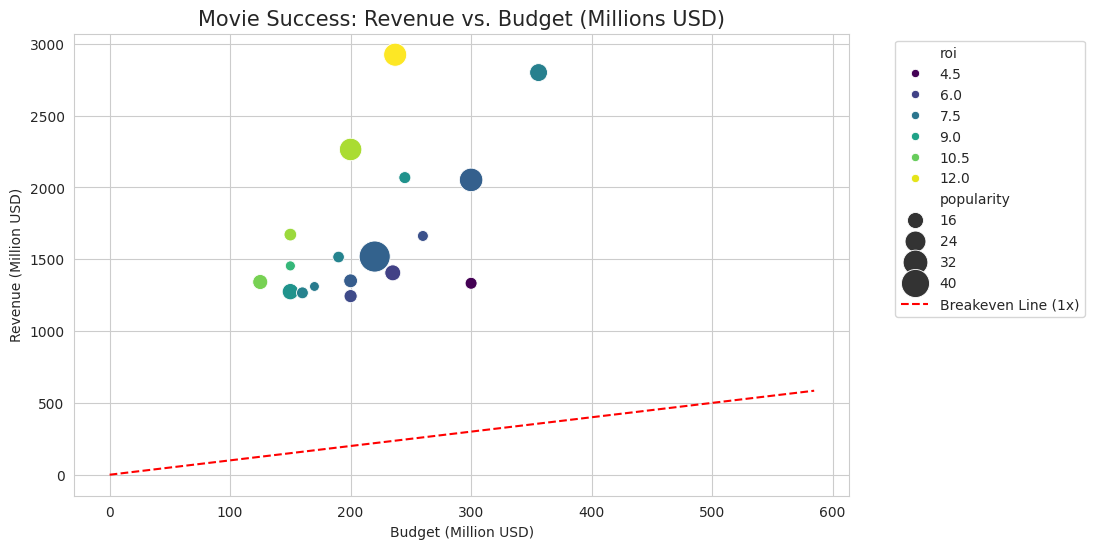

In [60]:
# Revenue vs. Budget Trends
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Scatter plot
sns.scatterplot(
    data=df_final,
    x='budget_musd',
    y='revenue_musd',
    size='popularity',
    hue='roi',
    palette='viridis',
    sizes=(50, 500)
)

# Add a diagonal line for breakeven (Revenue = Budget)
max_val = max(df_final['revenue_musd'].max(), df_final['budget_musd'].max())
plt.plot([0, max_val/5], [0, max_val/5], color='red', linestyle='--', label='Breakeven Line (1x)')

plt.title('Movie Success: Revenue vs. Budget (Millions USD)', fontsize=15)
plt.xlabel('Budget (Million USD)')
plt.ylabel('Revenue (Million USD)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

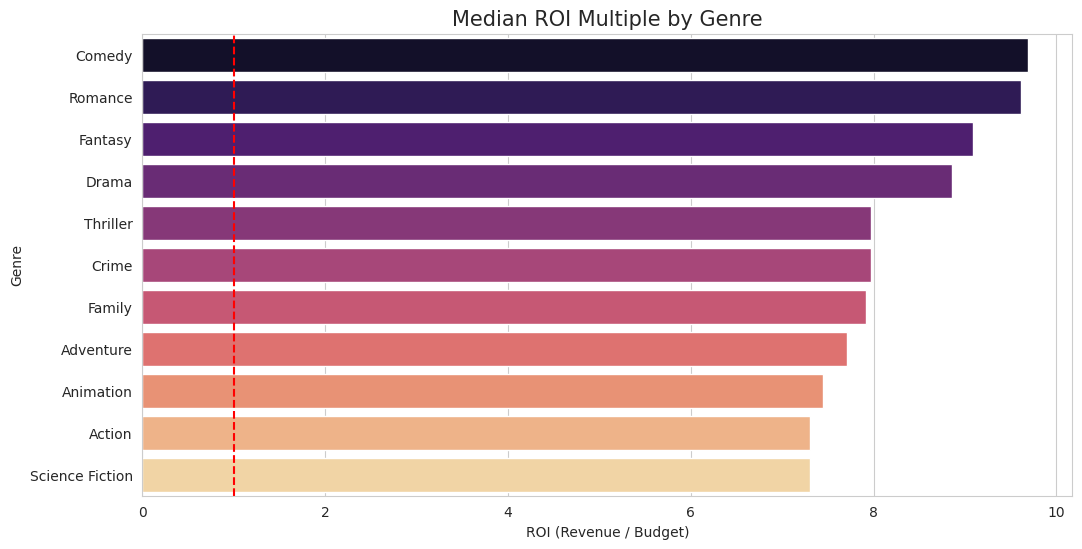

In [76]:
# ROI Distribution by Genre
genre_roi = (
    df_final[['id', 'genres', 'revenue_musd', 'roi', 'budget_musd']]
    .dropna(subset=['genres'])
    .assign(genres = df_final['genres'].str.split('|'))
    .explode('genres')
    .groupby('genres')["roi"]
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
# sns.barplot(x=genre_roi.values, y=genre_roi.index, palette='magma')
sns.barplot(
    x=genre_roi.values,
    y=genre_roi.index,
    hue=genre_roi.index,
    palette='magma',
    legend=False
)
plt.title('Median ROI Multiple by Genre', fontsize=15)
plt.xlabel('ROI (Revenue / Budget)')
plt.ylabel('Genre')
plt.axvline(1, color='red', linestyle='--', label='Breakeven (1x)')
plt.show()

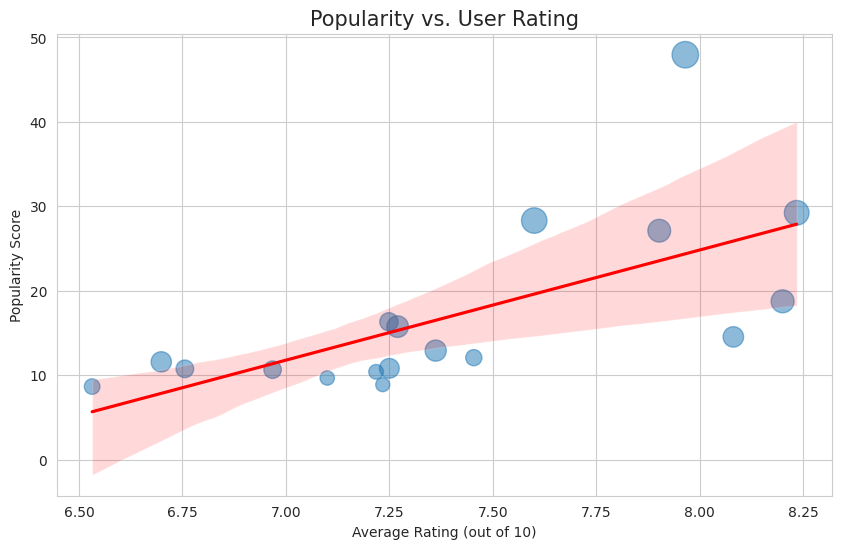

In [62]:
# Popularity vs. Rating
plt.figure(figsize=(10, 6))
sns.regplot(data=df_final, x='vote_average', y='popularity',
            scatter_kws={'s':df_final['vote_count']/100, 'alpha':0.5}, # Size based on vote count
            line_kws={'color':'red'})

plt.title('Popularity vs. User Rating', fontsize=15)
plt.xlabel('Average Rating (out of 10)')
plt.ylabel('Popularity Score')
plt.show()

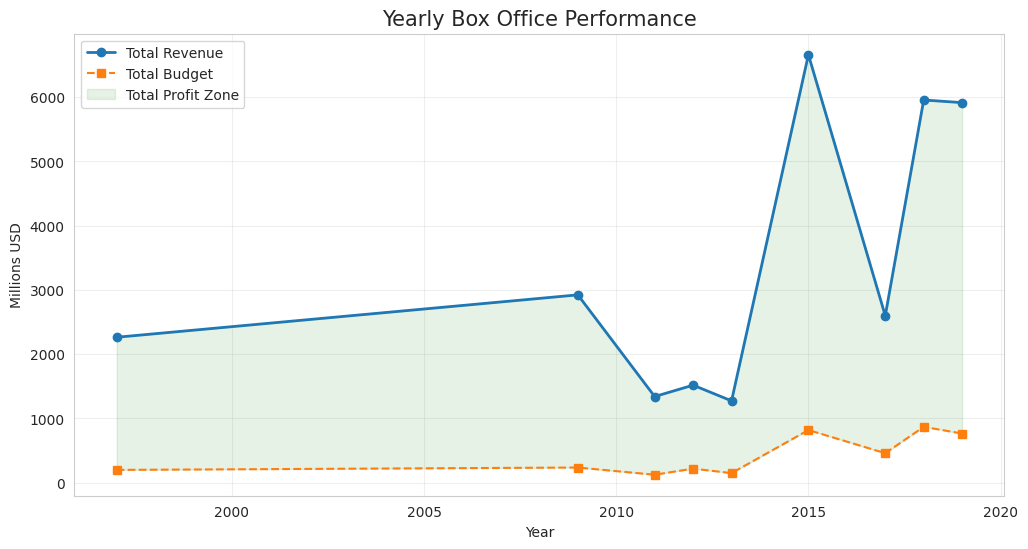

In [63]:
# Yearly Trends in Box Office Performance
# Extract Year and group
yearly_trends = (
    df_final
    .assign(year = df_final['release_date'].dt.year)
    .groupby('year')
    .agg({'revenue_musd': 'sum', 'budget_musd': 'sum'})
)

plt.figure(figsize=(12, 6))
plt.plot(yearly_trends.index, yearly_trends['revenue_musd'], marker='o', label='Total Revenue', linewidth=2)
plt.plot(yearly_trends.index, yearly_trends['budget_musd'], marker='s', label='Total Budget', linestyle='--')

plt.fill_between(
    yearly_trends.index,
     yearly_trends['budget_musd'],
     yearly_trends['revenue_musd'],
     color='green',
     alpha=0.1,
     label='Total Profit Zone'
)

plt.title('Yearly Box Office Performance', fontsize=15)
plt.xlabel('Year')
plt.ylabel('Millions USD')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

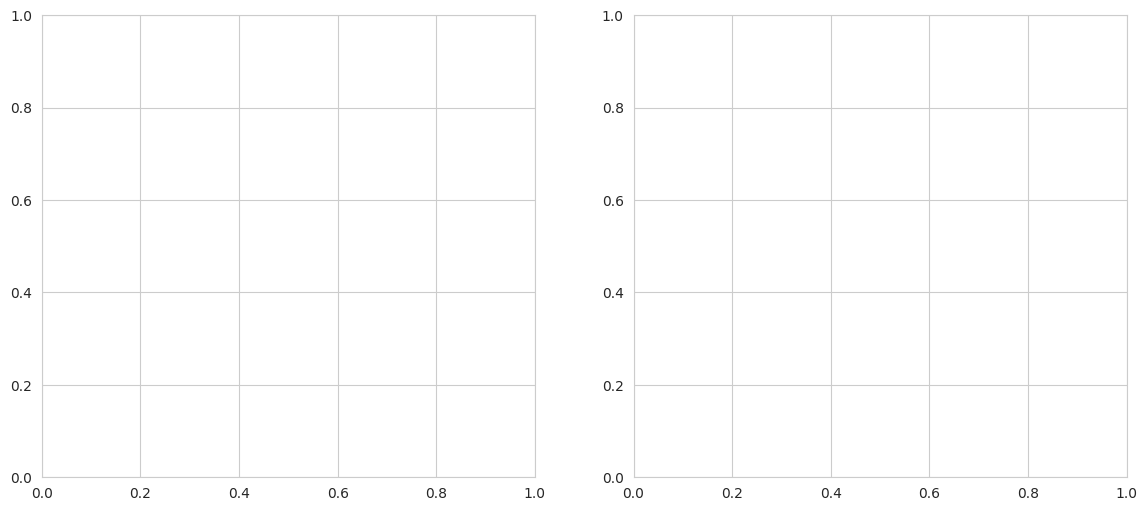

In [79]:
# Comparison of Franchise vs. Standalone Success
df_viz = (
    df_final
    .assign(type = np.where(df_final['belongs_to_collection'].isna(), "Standalone", "Franchise"))
)

fig, ax = plt.subplots(2, 2, figsize=(14, 6))

# # Subplot 1: Mean Revenue
# sns.barplot(
#     data=df_viz,
#     x='type',
#     y='revenue_musd',
#     hue='type',
#     ax=ax[0],
#     palette='Blues',
#     legend=False
# )
#
# ax[0].set_title('Mean Revenue: Franchise vs Standalone')
# ax[0].set_ylabel('Mean Revenue (MUSD)')
#
# # Subplot 2: Median ROI
# sns.barplot(
#     data=df_viz,
#     x='type',
#     y='roi',
#     estimator=np.median,
#     hue='type',
#     ax=ax[1],
#     palette='Oranges',
#     legend=False
# )
# ax[1].set_title('Median ROI: Franchise vs Standalone')
# ax[1].set_ylabel('Median ROI (Multiple)')
#
# plt.tight_layout()
# plt.show()